# 0-Curv, 1-Curv & Topological Comparison for Various Datasets

## 1. Imports and Dataset Upload

In [46]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

In [47]:
# parameters for loading the maps
hidden_channels = 16
dataset = "citeseer"
layers = 2
epochs = 300

# load the maps for each layer
MAPS = []
for layer in range(layers):
    map_path = f"../results/maps/{dataset}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold0_seed43.pt"
    MAPS.append(torch.load(map_path))

In [48]:
# convert the maps to pandas DataFrames for easier analysis
DF = []

for maps in MAPS:
    df = pd.DataFrame(maps.cpu().tolist(), columns=["source", "target", "map_value"])
    df[["source", "target"]] = df[["source", "target"]].astype(int)
    df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
    DF.append(df)

display(DF[0].head())

,source,target,map_value
0,0,628,0.186989
1,1,158,-0.787894
2,1,486,-0.748806
3,1,1097,-0.705461
4,1,2919,-0.827407


## 2. Largest Connected Component

In [49]:
# Forman-Bochner decomposition of the Laplacian matrix
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])
    #B=B.astype(int)
    F=L-B
    
    return B , F

In [50]:
B_list = []

L0_LIST = []
L1_LIST = []

f0_list = []
f1_list = []

ev0_list = []
ev1_list = []

e0_list = []
e1_list = []

G_list = []
lcc_nodes_list = []
lcc_edges_list = []

f0_top_list = []
f1_top_list = []
L0_top_list = []
L1_top_list = []

for df in DF:
    df = df.copy()
    df[["source", "target"]] = df[["source", "target"]].astype(int)

    # Signed value
    df["signed_map"] = np.where(
        df["target"] < df["source"],
        df["map_value"],
        -df["map_value"]
    )

    # Canonical undirected edge label
    df["edge"] = df.apply(
        lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),
        axis=1
    )

    # --------------------------------------------------
    # 1. Build the graph first
    # --------------------------------------------------
    G_full = nx.Graph()
    G_full.add_edges_from(df["edge"].tolist())

    # If you want to include isolated nodes from 0,...,max_node:
    max_node = max(df["source"].max(), df["target"].max())
    G_full.add_nodes_from(range(max_node + 1))

    # --------------------------------------------------
    # 2. Extract largest connected component
    # --------------------------------------------------
    largest_cc = max(nx.connected_components(G_full), key=len)
    lcc_nodes = sorted(largest_cc)

    G = G_full.subgraph(lcc_nodes).copy()

    # Canonical lexicographic edge ordering
    lcc_edges = sorted((min(u, v), max(u, v)) for u, v in G.edges())

    # --------------------------------------------------
    # 3. Restrict dataframe to LCC edges only
    # --------------------------------------------------
    lcc_edge_set = set(lcc_edges)

    df_lcc = df[df["edge"].isin(lcc_edge_set)].copy()

    # Restrict rows to nodes in the LCC as well
    df_lcc = df_lcc[
        df_lcc["source"].isin(lcc_nodes) & df_lcc["target"].isin(lcc_nodes)
    ].copy()

    # --------------------------------------------------
    # 4. Build B on the LCC only
    # --------------------------------------------------
    B = df_lcc.pivot(index="source", columns="edge", values="signed_map")
    B = B.reindex(index=lcc_nodes, columns=lcc_edges, fill_value=0)
    B.index.name = "node"
    B.fillna(0, inplace=True)

    B_np = B.to_numpy(dtype=float)

    # --------------------------------------------------
    # 5. Compute Laplacians
    # --------------------------------------------------
    L0_un = B_np @ B_np.T
    L1_un = B_np.T @ B_np

    d0 = np.diag(L0_un)

    # Safe inverse handling
    with np.errstate(divide="ignore", invalid="ignore"):
        d0_inv = np.where(d0 > 0, 1.0 / d0, 0.0)
        d0_inv_sqrt = np.where(d0 > 0, 1.0 / np.sqrt(d0), 0.0)

    D0_inv = np.diag(d0_inv)
    D0_inv_sqrt = np.diag(d0_inv_sqrt)

    L0 = D0_inv_sqrt @ L0_un @ D0_inv_sqrt
    L1 = B_np.T @ D0_inv @ B_np

    # Topological Laplacians for sanity check
    B_top = nx.incidence_matrix(G).todense()
    
    L0_top = B_top @ B_top.T
    L1_top = B_top.T @ B_top
    
    B0_top, F0_top = fbc(L0_top)
    B1_top, F1_top = fbc(L1_top)
    
    f0_top = np.diag(F0_top)
    f1_top = np.diag(F1_top)

    f0_top_list.append(np.asarray(f0_top).ravel())
    f1_top_list.append(np.asarray(f1_top).ravel())
    L0_top_list.append(np.asarray(L0_top))
    L1_top_list.append(np.asarray(L1_top))

    # --------------------------------------------------
    # 6. FBC decomposition
    # --------------------------------------------------
    B1, F1 = fbc(L1)
    B0, F0 = fbc(L0)

    # --------------------------------------------------
    # 7. Store results
    # --------------------------------------------------
    G_list.append(G)
    lcc_nodes_list.append(lcc_nodes)
    lcc_edges_list.append(lcc_edges)

    B_list.append(B)

    L0_LIST.append(L0)
    L1_LIST.append(L1)

    f0_list.append(np.diag(F0))
    f1_list.append(np.diag(F1))

    e0, ev0 = np.linalg.eigh(L0)
    e1, ev1 = np.linalg.eigh(L1)

    ev0_list.append(ev0)
    ev1_list.append(ev1)
    e0_list.append(e0)
    e1_list.append(e1)

In [51]:
# Sanity checks
for i in range(len(DF)):
    print(f"Graph {i}:")
    print(f"  Number of nodes in LCC: {len(lcc_nodes_list[i])}")
    print(f"  Number of edges in LCC: {len(lcc_edges_list[i])}")
    print(f"  Shape of B: {B_list[i].shape}")
    print(f"  Shape of L0: {L0_LIST[i].shape}")
    print(f"  Shape of L1: {L1_LIST[i].shape}")
    print(f"  First 5 eigenvalues of L0: {e0_list[i][:5]}")
    print(f"  First 5 eigenvalues of L1: {e1_list[i][:5]}")

Graph 0:
  Number of nodes in LCC: 2120
  Number of edges in LCC: 3679
  Shape of B: (2120, 3679)
  Shape of L0: (2120, 2120)
  Shape of L1: (3679, 3679)
  First 5 eigenvalues of L0: [7.48133125e-05 1.17830672e-04 2.54145875e-04 2.86833757e-04
 4.17020033e-04]
  First 5 eigenvalues of L1: [-2.10975379e-15 -2.10033674e-15 -2.06883229e-15 -2.05568003e-15
 -2.05000750e-15]
Graph 1:
  Number of nodes in LCC: 2120
  Number of edges in LCC: 3679
  Shape of B: (2120, 3679)
  Shape of L0: (2120, 2120)
  Shape of L1: (3679, 3679)
  First 5 eigenvalues of L0: [1.98489145e-06 4.68414347e-06 5.42561204e-06 1.32183647e-05
 2.10021692e-05]
  First 5 eigenvalues of L1: [-2.14238994e-15 -1.96162745e-15 -1.94435505e-15 -1.90564018e-15
 -1.87768696e-15]


# 3. Visualisations

In [52]:
def plot_f0_layers(G, f0_list, f0_top=None, title="Node-wise $f_0$ comparison"):
    layers = len(f0_list)
    ncols = layers + (1 if f0_top is not None else 0)

    pos = nx.spring_layout(G, seed=42)
    cmap = plt.cm.coolwarm

    all_vals = [np.asarray(f0, dtype=float) for f0 in f0_list]
    if f0_top is not None:
        all_vals.append(np.asarray(f0_top, dtype=float))

    finite_vals = np.concatenate([v[np.isfinite(v)] for v in all_vals if np.isfinite(v).any()])
    norm = plt.Normalize(vmin=finite_vals.min(), vmax=finite_vals.max())

    fig, ax = plt.subplots(
        2, ncols,
        figsize=(4 * ncols, 8),
        gridspec_kw={"height_ratios": [3, 1.4]}
    )
    if ncols == 1:
        ax = np.array(ax).reshape(2, 1)

    for layer in range(layers):
        vals = np.asarray(f0_list[layer], dtype=float)

        axg = ax[0, layer]
        nx.draw_networkx_nodes(G, pos=pos, ax=axg, node_color=cmap(norm(vals)), node_size=2)
        nx.draw_networkx_edges(G, pos=pos, ax=axg, width=0.5, alpha=0.1)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=axg, label=r"$f_0$")
        axg.set_title(f"$f_0$ at layer {layer+1}", fontweight="bold")
        axg.axis("off")

        axh = ax[1, layer]
        vals_finite = vals[np.isfinite(vals)]
        if vals_finite.size > 0:
            axh.hist(vals_finite, bins=20, edgecolor="black")
            axh.axvline(0, color="red", linestyle="--", linewidth=1)
        else:
            axh.text(0.5, 0.5, "No finite values", ha="center", va="center", transform=axh.transAxes)
        axh.set_title(f"Distribution layer {layer+1}")
        axh.set_xlabel(r"$f_0$")
        axh.set_ylabel("Frequency")
        axh.grid(alpha=0.3)

    if f0_top is not None:
        vals = np.asarray(f0_top, dtype=float)

        axg = ax[0, -1]
        nx.draw_networkx_nodes(G, pos=pos, ax=axg, node_color=cmap(norm(vals)), node_size=2)
        nx.draw_networkx_edges(G, pos=pos, ax=axg, width=0.5, alpha=0.1)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=axg, label=r"$f_0$")
        axg.set_title("Topological $f_0$", fontweight="bold")
        axg.axis("off")

        axh = ax[1, -1]
        vals_finite = vals[np.isfinite(vals)]
        if vals_finite.size > 0:
            axh.hist(vals_finite, bins=20, edgecolor="black")
            axh.axvline(0, color="red", linestyle="--", linewidth=1)
        axh.set_title("Topological distribution")
        axh.set_xlabel(r"$f_0$")
        axh.set_ylabel("Frequency")
        axh.grid(alpha=0.3)

    fig.suptitle(title, fontsize=18, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

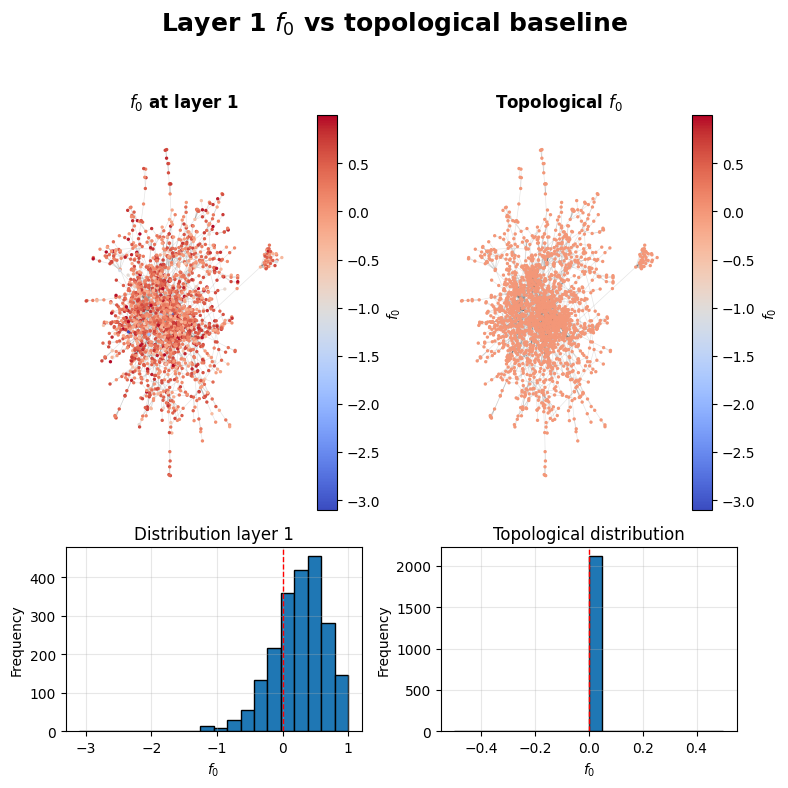

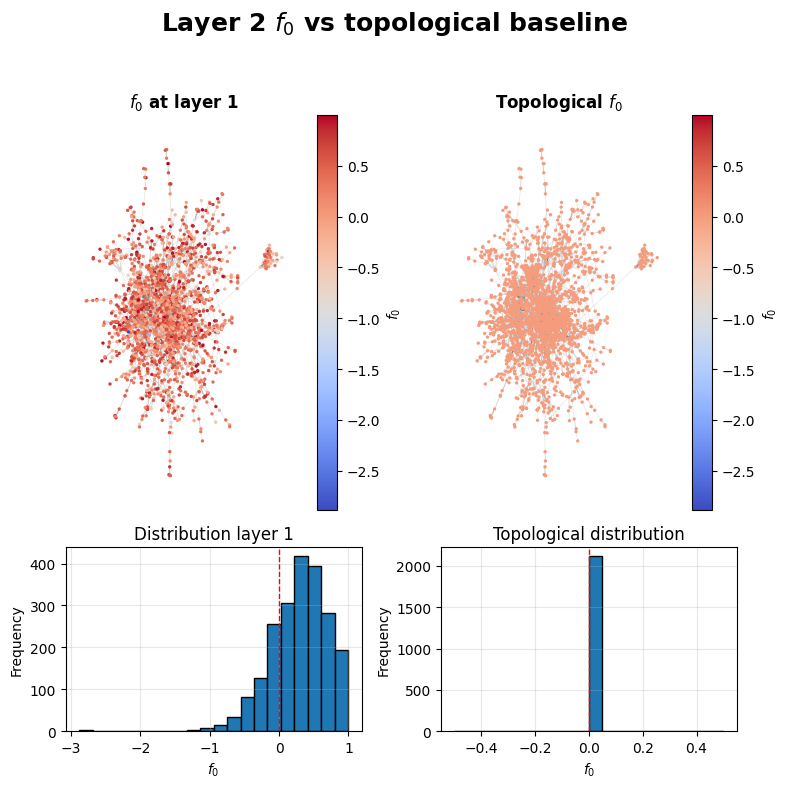

In [53]:
for k in range(len(DF)):
    plot_f0_layers(G_list[k], [f0_list[k]], f0_top=f0_top_list[k], title=f"Layer {k+1} $f_0$ vs topological baseline")

In [54]:
def plot_f1_layers(G, f1_list, f1_top=None, title="Edge-wise $f_1$ comparison"):
    layers = len(f1_list)
    ncols = layers + (1 if f1_top is not None else 0)

    pos = nx.spring_layout(G, seed=42)
    cmap = plt.cm.coolwarm

    edge_order = sorted((min(u, v), max(u, v)) for u, v in G.edges())

    all_vals = [np.asarray(f1, dtype=float) for f1 in f1_list]
    # if f1_top is not None:
    #     all_vals.append(np.asarray(f1_top, dtype=float))

    finite_vals = np.concatenate([v[np.isfinite(v)] for v in all_vals if np.isfinite(v).any()])
    norm = plt.Normalize(vmin=finite_vals.min(), vmax=finite_vals.max())

    fig, ax = plt.subplots(
        2, ncols,
        figsize=(4 * ncols, 8),
        gridspec_kw={"height_ratios": [3, 1.4]}
    )
    if ncols == 1:
        ax = np.array(ax).reshape(2, 1)

    for layer in range(layers):
        vals = np.asarray(f1_list[layer], dtype=float)

        axg = ax[0, layer]
        nx.draw_networkx_nodes(G, pos=pos, ax=axg, node_color='k', node_size=1, alpha=.1)
        nx.draw_networkx_edges(
            G, pos=pos, ax=axg,
            edgelist=edge_order,
            edge_color=cmap(norm(vals)),
            width=2
        )
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=axg, label=r"$f_1$")
        axg.set_title(f"$f_1$ at layer {layer+1}", fontweight="bold")
        axg.axis("off")

        axh = ax[1, layer]
        vals_finite = vals[np.isfinite(vals)]
        if vals_finite.size > 0:
            axh.hist(vals_finite, bins=20, edgecolor="black")
            axh.axvline(0, color="red", linestyle="--", linewidth=1)
        axh.set_title(f"Distribution layer {layer+1}")
        axh.set_xlabel(r"$f_1$")
        axh.set_ylabel("Frequency")
        axh.grid(alpha=0.3)

    if f1_top is not None:
        vals = np.asarray(f1_top, dtype=float)

        axg = ax[0, -1]
        nx.draw_networkx_nodes(G, pos=pos, ax=axg, node_color='k', node_size=1, alpha=.1)
        nx.draw_networkx_edges(
            G, pos=pos, ax=axg,
            edgelist=edge_order,
            edge_color=cmap(norm(vals)),
            width=2
        )
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=axg, label=r"$f_1$")
        axg.set_title(f"Topological $f_1$", fontweight="bold")
        axg.axis("off")

        axh = ax[1, -1]
        vals_finite = vals[np.isfinite(vals)]
        if vals_finite.size > 0:
            axh.hist(vals_finite, bins=20, edgecolor="black")
            axh.axvline(0, color="red", linestyle="--", linewidth=1)
        axh.set_title("Topological distribution")
        axh.set_xlabel(r"$f_1$")
        axh.set_ylabel("Frequency")
        axh.grid(alpha=0.3)

    fig.suptitle(title, fontsize=18, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

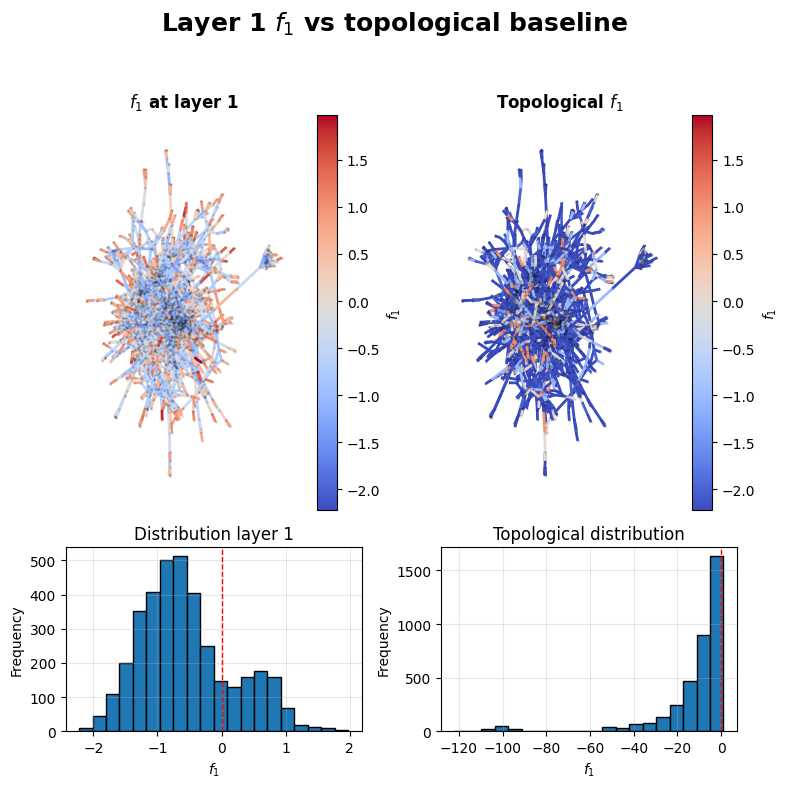

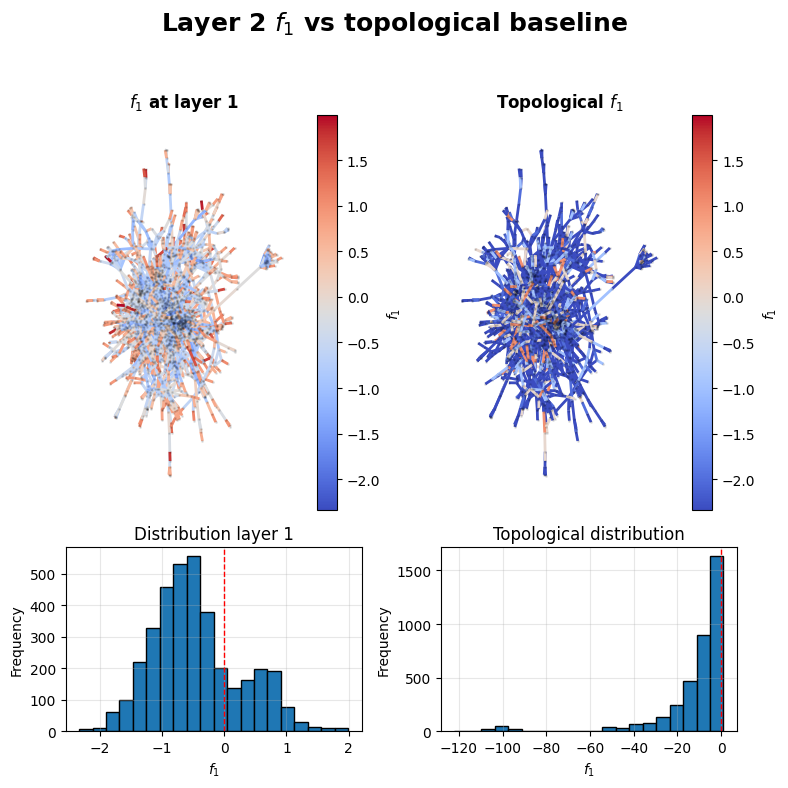

In [55]:
for k in range(len(DF)):
    plot_f1_layers(G_list[k], [f1_list[k]], f1_top=f1_top_list[k], title=f"Layer {k+1} $f_1$ vs topological baseline")